In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import re
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

def gerar_dataset_vendas(n_registros=200, seed=42):
    """Gera um dataset sintético de vendas com dados intencionalmente sujos."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse", "Headset"]
    categorias = {
        "Notebook": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Monitor": "Computadores",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos",
        "Headset": "Periféricos"
    }

    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 51)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):

        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)

        preco_base = {
            "Notebook": 3500,
            "Smartphone": 2200,
            "Tablet": 1800,
            "Monitor": 1200,
            "Teclado": 250,
            "Mouse": 120,
            "Headset": 350
        }[produto]

        preco = round(preco_base * random.uniform(0.85, 1.15), 2)
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None
        if random.random() < 0.04:
            preco = None
        if random.random() < 0.03:
            produto = "  " + produto

        dados.append({
            "id_venda": i + 1,
            "data_venda": data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVÁLIDA",
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

# Gerar e salvar dataset
df_bruto = gerar_dataset_vendas()
df_bruto.to_csv("vendas.csv", index=False)

print(f"Dataset gerado com {len(df_bruto)} registros.")
print(df_bruto.head(5))

Dataset gerado com 200 registros.
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-05-20  Cliente_035       Mouse   Periféricos   Sudeste   
1         2  2024-02-17  Cliente_042     Teclado   Periféricos     Norte   
2         3  2024-05-22  Cliente_022     Monitor  Computadores  Nordeste   
3         4  2024-06-21  Cliente_017  Smartphone     Celulares   Sudeste   
4         5  2024-07-12  Cliente_024       Mouse   Periféricos     Norte   

   quantidade  preco_unitario  
0         2.0          102.90  
1         7.0          214.88  
2         4.0             NaN  
3         4.0         2501.76  
4         8.0          121.30  


In [2]:
df_bruto.shape

(200, 8)

In [3]:
df_bruto.columns

Index(['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao',
       'quantidade', 'preco_unitario'],
      dtype='str')

In [4]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        200 non-null    int64  
 1   data_venda      200 non-null    str    
 2   cliente         200 non-null    str    
 3   produto         200 non-null    str    
 4   categoria       200 non-null    str    
 5   regiao          200 non-null    str    
 6   quantidade      194 non-null    float64
 7   preco_unitario  190 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 12.6 KB


In [5]:
df_bruto.isnull().sum()

id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10
dtype: int64

In [6]:
df_bruto.describe()

,id_venda,quantidade,preco_unitario
count,200.000000,194.000000,190.000000
mean,100.500000,5.427835,1337.999789
std,57.879185,2.792931,1128.654914
min,1.000000,1.000000,102.900000
25%,50.750000,3.000000,264.015000
50%,100.500000,6.000000,1209.295000
75%,150.250000,8.000000,1991.257500
max,200.000000,10.000000,3996.800000


In [7]:
df_bruto.head(5)

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


In [8]:
df = df_bruto.copy()

In [9]:
df.head(5)

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


In [10]:
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame."""
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print(f"\nEstatísticas descritivas:\n{df.describe()}")


In [11]:
inspecionar_dados(df)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (200, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-05-20  Cliente_035       Mouse   Periféricos   Sudeste   
1         2  2024-02-17  Cliente_042     Teclado   Periféricos     Norte   
2         3  2024-05-22  Cliente_022     Monitor  Computadores  Nordeste   
3         4  2024-06-21  Cliente_017  Smartphone     Celular

In [12]:
def limpar_dados(df):
    """
    Limpa e trata o DataFrame de vendas.
    Retorna o DataFrame limpo e um relatório de limpeza.
    """
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}

    # 1. Remover espaços extras em colunas de texto
    colunas_texto = df.select_dtypes(include="object").columns
    for col in colunas_texto:
        df[col] = df[col].str.strip()

    # 2. Converter data e remover datas inválidas
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    n_datas_invalidas = df["data_venda"].isnull().sum()
    df = df.dropna(subset=["data_venda"])
    relatorio["datas_invalidas_removidas"] = n_datas_invalidas

    # 3. Remover linhas com quantidade ou preço nulos
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # 4. Garantir tipos numéricos corretos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    n_final = len(df)
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = n_final
    relatorio["registros_removidos_total"] = n_inicial - n_final

    print("\n=== RELATÓRIO DE LIMPEZA ===")
    for chave, valor in relatorio.items():
        print(f"  {chave}: {valor}")
    return df, relatorio


In [13]:
df, relatorio = limpar_dados(df)


=== RELATÓRIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 16
  registros_iniciais: 200
  registros_finais: 180
  registros_removidos_total: 20


C:\Users\PC\AppData\Local\Temp\ipykernel_7952\2737768871.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


In [14]:
def criar_colunas_derivadas(df):
    """Cria colunas calculadas e derivadas a partir do dataset limpo."""

    # Receita total por linha de venda
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Extração de componentes de data
    df["mes"] = df["data_venda"].dt.month
    df["mes_nome"] = df["data_venda"].dt.strftime("%B")  # nome do mês
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year

    # Classificação da receita por item com numpy.select (transformação condicional vetorizada)
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]
    classificacoes = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, classificacoes, default="Não Classificado")
    print("\n=== COLUNAS DERIVADAS CRIADAS ===")
    print(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())

    return df




In [15]:
df = criar_colunas_derivadas(df)


=== COLUNAS DERIVADAS CRIADAS ===
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-05-20         205.80    5        Q2        Baixo Valor
1 2024-02-17        1504.16    2        Q1        Médio Valor
3 2024-06-21       10007.04    6        Q2         Alto Valor
4 2024-07-12         970.40    7        Q3        Médio Valor
5 2024-04-26        3800.48    4        Q2        Médio Valor


In [16]:

def calcular_metricas(df):
    """Calcula e retorna métricas agregadas do dataset."""
    metricas = {}

    # Receita por mês
    por_mes = df.groupby("mes").agg(
        receita_total=("receita_total", "sum"),
        quantidade=("quantidade", "sum"),
        n_vendas=("id_venda", "count")
    ).reset_index().sort_values("mes")
    metricas["por_mes"] = por_mes

    # Top 5 produtos por receita
    top_produtos = df.groupby("produto")["receita_total"].sum()\
                     .sort_values(ascending=False).head(5).reset_index()
    metricas["top_produtos"] = top_produtos

    # Receita por categoria
    por_categoria = df.groupby("categoria")["receita_total"].sum().reset_index()
    metricas["por_categoria"] = por_categoria

    # Receita por região
    por_regiao = df.groupby("regiao").agg(
        receita_total=("receita_total", "sum"),
        media_ticket=("receita_total", "mean")
    ).reset_index().sort_values("receita_total", ascending=False)
    metricas["por_regiao"] = por_regiao

    # Exibição
    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))

    return metricas


In [17]:
metricas = calcular_metricas(df)
metricas


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       47169.34          45         9
   2       69968.85          91        15
   3      124532.20          88        17
   4      103611.52          75        15
   5      106602.03          89        14
   6      117334.85          75        15
   7      110935.66          99        19
   8      140320.55          81        13
   9       90627.26          63        10
  10      137350.13         118        20
  11       69554.97          65        12
  12      115925.56         105        21

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet      353176.81
  Notebook      350212.88
Smartphone      234977.18
   Monitor      190466.41
   Headset       58661.68

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares      588153.99
Computadores      540679.29
 Periféricos      105099.64

=== POR REGIAO ===
      regiao  receita_total  media_ticket
     Sudeste      329458.34   8447.649744
Centro-Oeste      24

{'por_mes':     mes  receita_total  quantidade  n_vendas
 0     1       47169.34          45         9
 1     2       69968.85          91        15
 2     3      124532.20          88        17
 3     4      103611.52          75        15
 4     5      106602.03          89        14
 5     6      117334.85          75        15
 6     7      110935.66          99        19
 7     8      140320.55          81        13
 8     9       90627.26          63        10
 9    10      137350.13         118        20
 10   11       69554.97          65        12
 11   12      115925.56         105        21,
 'top_produtos':       produto  receita_total
 0      Tablet      353176.81
 1    Notebook      350212.88
 2  Smartphone      234977.18
 3     Monitor      190466.41
 4     Headset       58661.68,
 'por_categoria':       categoria  receita_total
 0     Celulares      588153.99
 1  Computadores      540679.29
 2   Periféricos      105099.64,
 'por_regiao':          regiao  receita_total  

In [18]:
def segmentar_clientes(df):
    """Segmenta clientes pelo total gasto usando groupby e lambda."""

    clientes = df.groupby("cliente")["receita_total"].sum().reset_index()
    clientes.columns = ["cliente", "total_gasto"]

    # Classificação usando função lambda com condicionais
    clientes["segmento"] = clientes["total_gasto"].apply(
        lambda gasto: "Ouro" if gasto > 15000
                      else ("Prata" if gasto >= 5000 else "Bronze")
    )

    clientes = clientes.sort_values("total_gasto", ascending=False)

    print("\n=== SEGMENTAÇÃO DE CLIENTES ===")
    print(clientes.head(10).to_string(index=False))
    print(f"\nDistribuição de segmentos:\n{clientes['segmento'].value_counts()}")

    return clientes


In [19]:
segmentar_clientes(df)


=== SEGMENTAÇÃO DE CLIENTES ===
    cliente  total_gasto segmento
Cliente_015     82964.76     Ouro
Cliente_035     75402.52     Ouro
Cliente_048     62293.77     Ouro
Cliente_024     57381.21     Ouro
Cliente_006     50249.74     Ouro
Cliente_004     50106.56     Ouro
Cliente_032     45532.00     Ouro
Cliente_044     43513.88     Ouro
Cliente_016     42754.07     Ouro
Cliente_017     41983.05     Ouro

Distribuição de segmentos:
segmento
Ouro      30
Prata     11
Bronze     8
Name: count, dtype: int64


,cliente,total_gasto,segmento
13,Cliente_015,82964.76,Ouro
33,Cliente_035,75402.52,Ouro
46,Cliente_048,62293.77,Ouro
22,Cliente_024,57381.21,Ouro
5,Cliente_006,50249.74,Ouro
3,Cliente_004,50106.56,Ouro
30,Cliente_032,45532.00,Ouro
42,Cliente_044,43513.88,Ouro
14,Cliente_016,42754.07,Ouro
15,Cliente_017,41983.05,Ouro


In [20]:
def calcular_estatisticas_numpy(df):
    """Usa NumPy para calcular estatísticas sobre as receitas."""
    print("\n=== ESTATÍSTICAS COM NUMPY ===")

    receitas = df["receita_total"].dropna().to_numpy()  # Converte para array NumPy

    media = np.mean(receitas)
    mediana = np.median(receitas)
    desvio_padrao = np.std(receitas)
    total = np.sum(receitas)
    p25 = np.percentile(receitas, 25)
    p75 = np.percentile(receitas, 75)

    print(f"  Receita média por venda:    R$ {media:.2f}")
    print(f"  Receita mediana por venda:  R$ {mediana:.2f}")
    print(f"  Desvio padrão:              R$ {desvio_padrao:.2f}")
    print(f"  Receita total:              R$ {total:.2f}")
    print(f"  Percentil 25 (Q1):          R$ {p25:.2f}")
    print(f"  Percentil 75 (Q3):          R$ {p75:.2f}")

    # Broadcasting: normalizar receitas entre 0 e 1
    receitas_normalizadas = (receitas - receitas.min()) / (receitas.max() - receitas.min())
    print(f"\n  Receitas normalizadas (primeiros 5): {receitas_normalizadas[:5].round(4)}")

    # Operação vetorizada: identificar vendas acima da média sem loop
    acima_da_media = receitas[receitas > media]
    print(f"\n  Vendas acima da média: {len(acima_da_media)} de {len(receitas)}")

    return {
        "media": media, "mediana": mediana,
        "desvio_padrao": desvio_padrao, "total": total
    }



In [21]:
calcular_estatisticas_numpy(df)


=== ESTATÍSTICAS COM NUMPY ===
  Receita média por venda:    R$ 6855.18
  Receita mediana por venda:  R$ 3899.61
  Desvio padrão:              R$ 6673.94
  Receita total:              R$ 1233932.92
  Percentil 25 (Q1):          R$ 1267.56
  Percentil 75 (Q3):          R$ 10976.68

  Receitas normalizadas (primeiros 5): [0.     0.042  0.3168 0.0247 0.1162]

  Vendas acima da média: 74 de 180


{'media': np.float64(6855.182888888889),
 'mediana': np.float64(3899.6099999999997),
 'desvio_padrao': np.float64(6673.944560719069),
 'total': np.float64(1233932.92)}

In [22]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """Gera e exporta visualizações dos dados de vendas."""
    os.makedirs(output_dir, exist_ok=True)

    # Configurações visuais globais
    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.figsize"] = (12, 6)
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12

    # --- Gráfico 1: Receita por Mês (linha) ---
    fig, ax = plt.subplots()
    por_mes = metricas["por_mes"]
    ax.plot(por_mes["mes"], por_mes["receita_total"], marker="o", linewidth=2, color="#2196F3")
    ax.fill_between(por_mes["mes"], por_mes["receita_total"], alpha=0.15, color="#2196F3")
    ax.set_title("Receita Total por Mês (2024)")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita Total (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun",
                         "Jul","Ago","Set","Out","Nov","Dez"], rotation=45)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "vendas_por_mes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    # --- Gráfico 2: Top 5 Produtos (barras horizontais) ---
    fig, ax = plt.subplots()
    top = metricas["top_produtos"]
    sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    for container in ax.containers:
        ax.bar_label(container, fmt="R$ %.0f", padding=5)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "top_produtos.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    # --- Gráfico 3: Distribuição de Receita por Região (boxplot) ---
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")
    ax.set_title("Distribuição de Receita por Transação – Por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    caminho = os.path.join(output_dir, "distribuicao_regioes.png")
    plt.savefig(caminho, dpi=150)
    plt.show()
    plt.close()
    print(f"  Gráfico exportado: {caminho}")

    print("\n=== VISUALIZAÇÕES GERADAS COM SUCESSO ===")


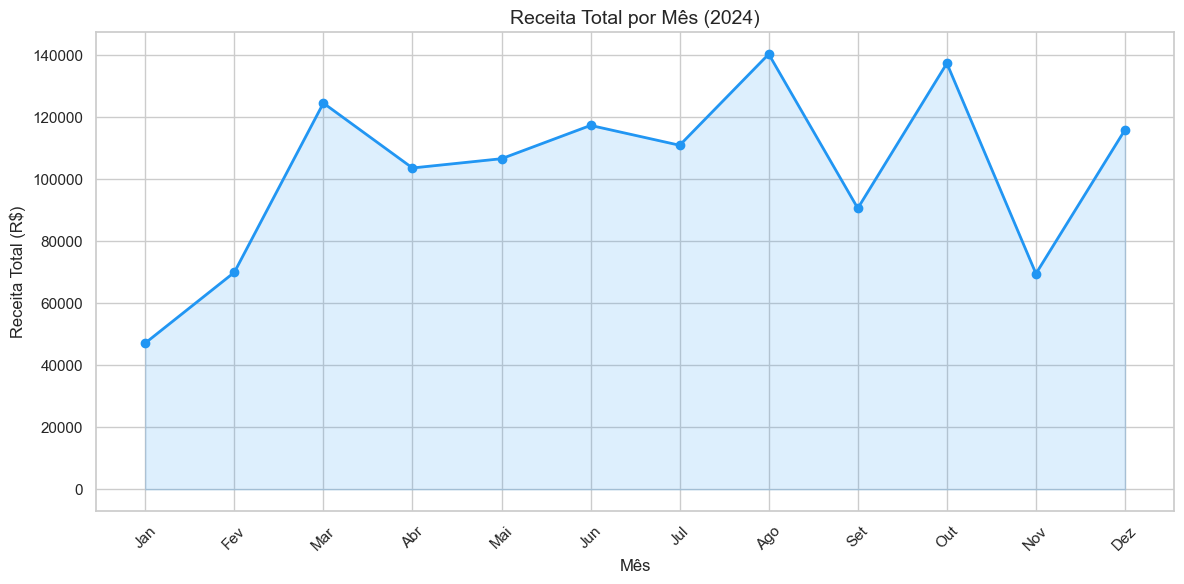

  Gráfico exportado: outputs/graficos\vendas_por_mes.png


C:\Users\PC\AppData\Local\Temp\ipykernel_7952\3991833871.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")


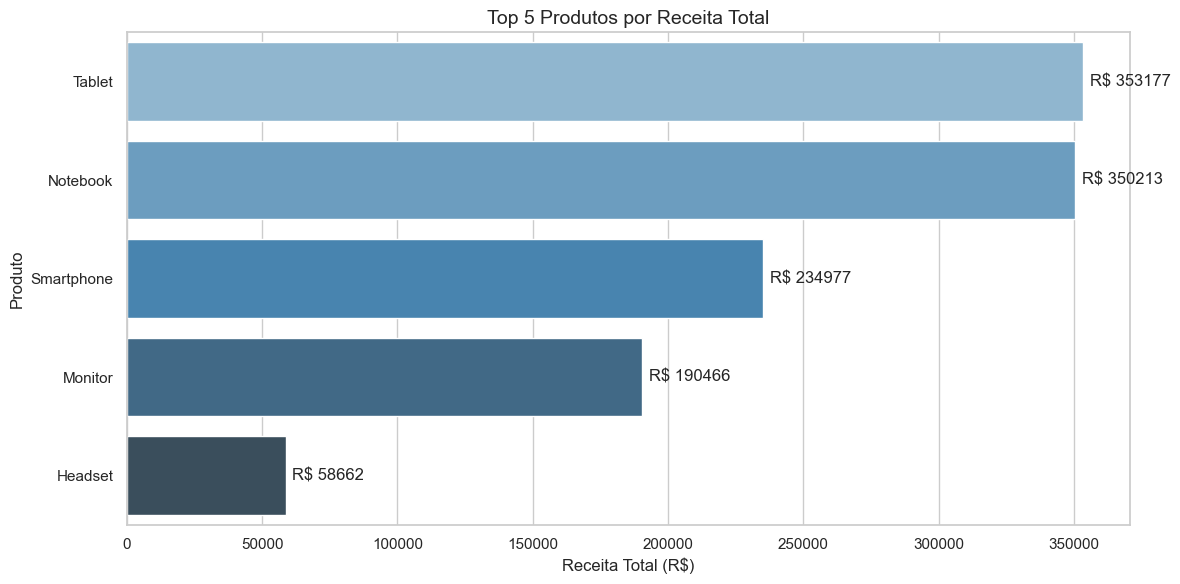

  Gráfico exportado: outputs/graficos\top_produtos.png


C:\Users\PC\AppData\Local\Temp\ipykernel_7952\3991833871.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")


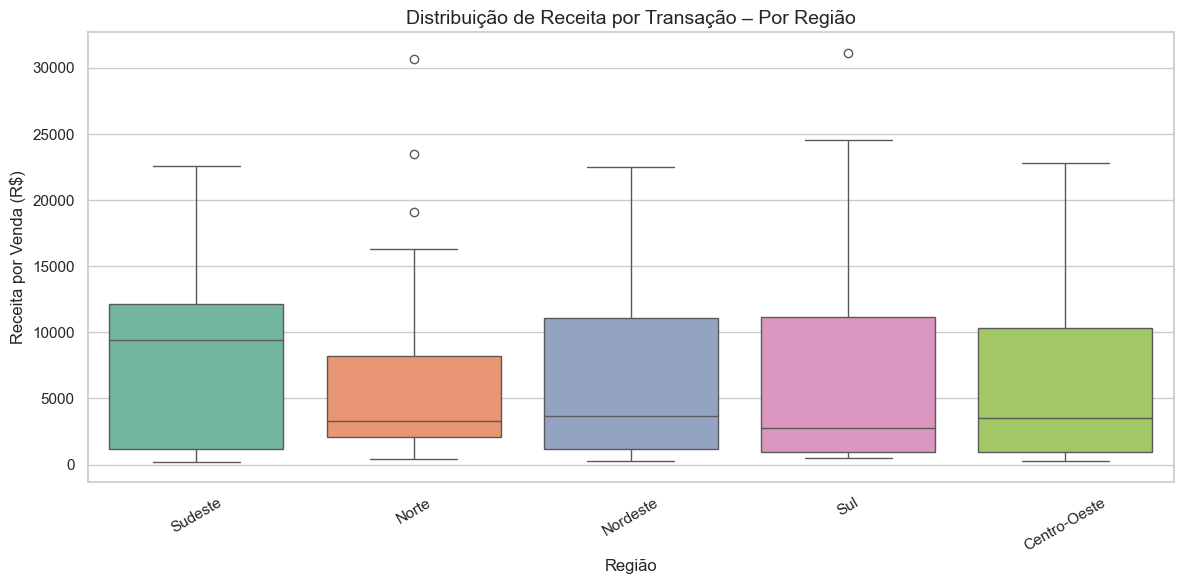

  Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===


In [23]:
gerar_visualizacoes(df, metricas)

In [24]:
class AnalisadorDeVendas:
    """
    Classe responsável por encapsular o pipeline de análise de vendas.
    Mantém o estado do DataFrame e os resultados intermediários.
    """

    def __init__(self, caminho_arquivo):
        """Inicializa o analisador com o caminho do arquivo de dados."""
        self.caminho_arquivo = caminho_arquivo
        self.df_bruto = None
        self.df_limpo = None
        self.metricas = {}
        self.clientes = None
        self.relatorio_limpeza = {}

    def carregar(self):
        """Lê o arquivo CSV e armazena o DataFrame bruto."""
        self.df_bruto = pd.read_csv(self.caminho_arquivo)
        print(f"[AnalisadorDeVendas] Arquivo carregado: {self.caminho_arquivo}")
        print(f"  Registros carregados: {len(self.df_bruto)}")
        return self

    def limpar(self):
        """Limpa os dados e armazena o DataFrame tratado."""
        self.df_limpo, self.relatorio_limpeza = limpar_dados(self.df_bruto.copy())
        return self

    def transformar(self):
        """Aplica transformações e cria colunas derivadas."""
        self.df_limpo = criar_colunas_derivadas(self.df_limpo)
        return self

    def analisar(self):
        """Calcula métricas e segmentações."""
        self.metricas = calcular_metricas(self.df_limpo)
        self.clientes = segmentar_clientes(self.df_limpo)
        calcular_estatisticas_numpy(self.df_limpo)
        return self

    def visualizar(self):
        """Gera e exporta os gráficos."""
        gerar_visualizacoes(self.df_limpo, self.metricas)
        return self

    def exportar_relatorio(self, caminho="outputs/relatorio_resumo.csv"):
        """Exporta o relatório de métricas por mês em CSV."""
        os.makedirs("outputs", exist_ok=True)
        self.metricas["por_mes"].to_csv(caminho, index=False)
        print(f"\n[AnalisadorDeVendas] Relatório exportado: {caminho}")
        return self

    def resumo(self):
        """Exibe um resumo executivo do pipeline."""
        print("\n" + "="*50)
        print("       RESUMO EXECUTIVO – SALESINSIGHT PY")
        print("="*50)
        print(f"  Arquivo analisado:      {self.caminho_arquivo}")
        print(f"  Registros brutos:       {self.relatorio_limpeza.get('registros_iniciais', 'N/A')}")
        print(f"  Registros limpos:       {self.relatorio_limpeza.get('registros_finais', 'N/A')}")
        receita = self.df_limpo["receita_total"].sum() if self.df_limpo is not None else 0
        print(f"  Receita total anual:    R$ {receita:,.2f}")
        if self.clientes is not None:
            top = self.clientes.iloc[0]
            print(f"  Cliente top:            {top['cliente']} (R$ {top['total_gasto']:,.2f})")
        print("="*50)


[AnalisadorDeVendas] Arquivo carregado: vendas.csv
  Registros carregados: 200

=== RELATÓRIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 16
  registros_iniciais: 200
  registros_finais: 180
  registros_removidos_total: 20

=== COLUNAS DERIVADAS CRIADAS ===
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-05-20         205.80    5        Q2        Baixo Valor
1 2024-02-17        1504.16    2        Q1        Médio Valor
3 2024-06-21       10007.04    6        Q2         Alto Valor
4 2024-07-12         970.40    7        Q3        Médio Valor
5 2024-04-26        3800.48    4        Q2        Médio Valor

=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       47169.34          45         9
   2       69968.85          91        15
   3      124532.20          88        17
   4      103611.52          75        15
   5      106602.03          89        14
   6      117334.85          75        15
   7      110935.66          99

C:\Users\PC\AppData\Local\Temp\ipykernel_7952\2737768871.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


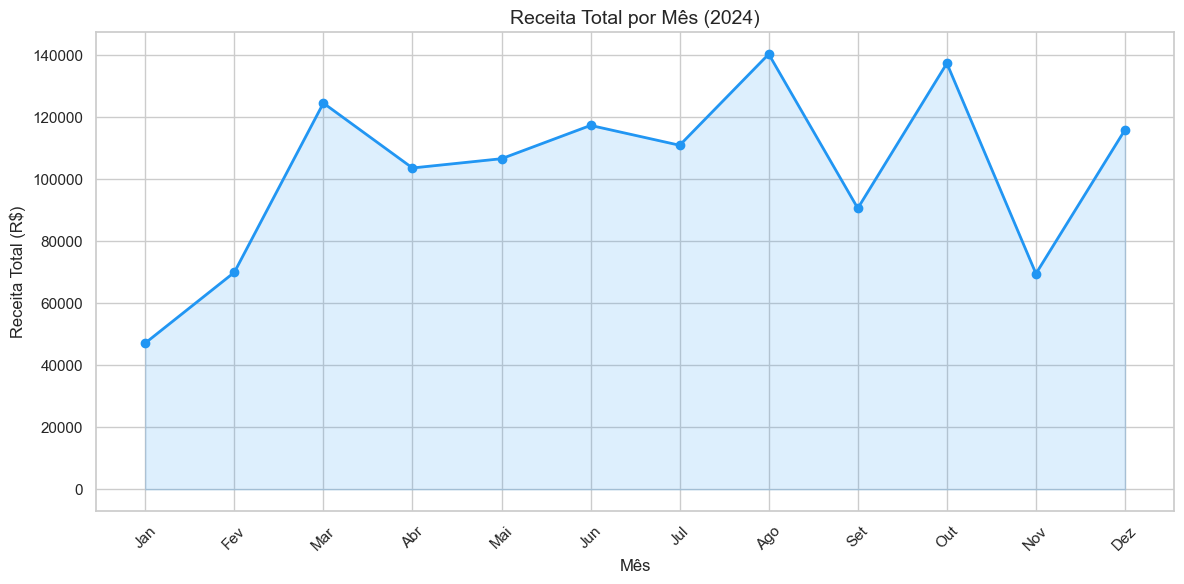

  Gráfico exportado: outputs/graficos\vendas_por_mes.png


C:\Users\PC\AppData\Local\Temp\ipykernel_7952\3991833871.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")


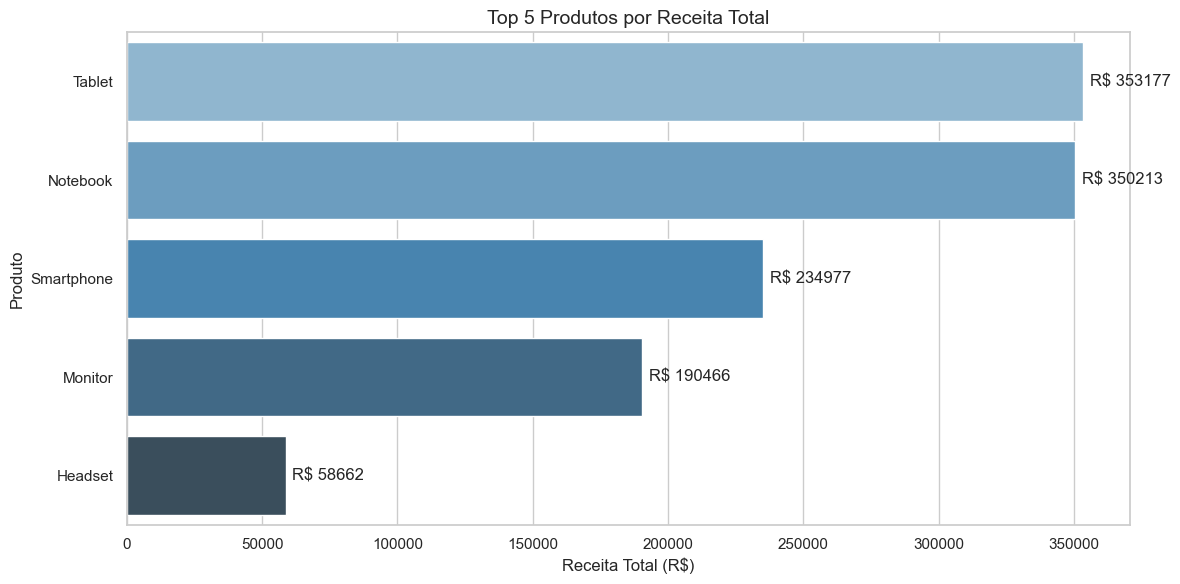

  Gráfico exportado: outputs/graficos\top_produtos.png


C:\Users\PC\AppData\Local\Temp\ipykernel_7952\3991833871.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")


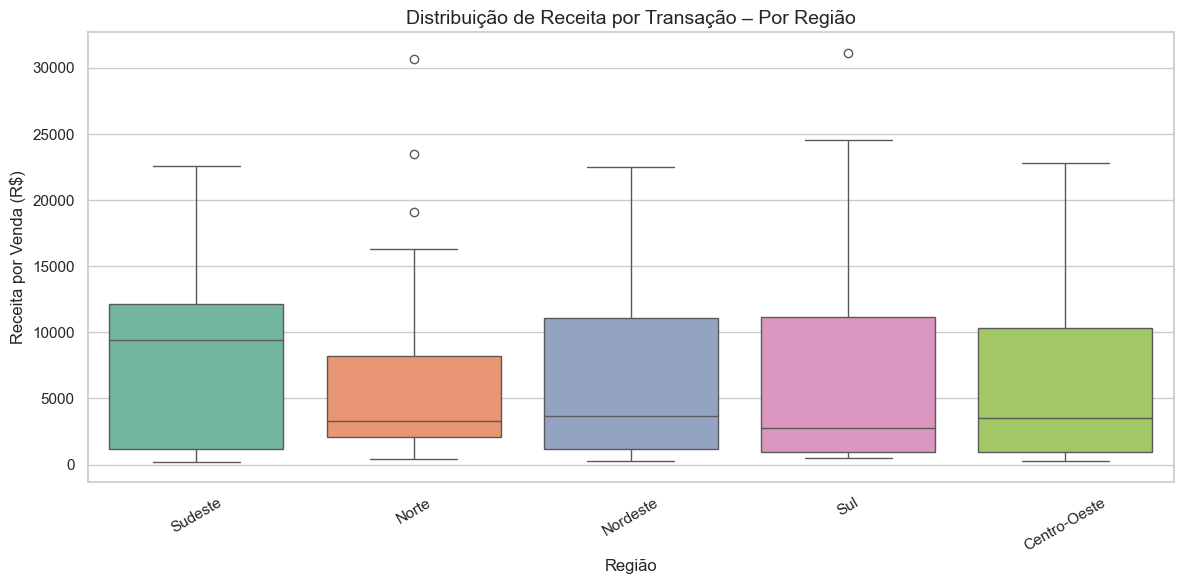

  Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===

       RESUMO EXECUTIVO – SALESINSIGHT PY
  Arquivo analisado:      vendas.csv
  Registros brutos:       200
  Registros limpos:       180
  Receita total anual:    R$ 1,233,932.92
  Cliente top:            Cliente_015 (R$ 82,964.76)


In [25]:
analisador = AnalisadorDeVendas("vendas.csv")

analisador.carregar()\
          .limpar()\
          .transformar()\
          .analisar()\
          .visualizar()\
          .resumo()

In [26]:
class AnalisadorComProjecao(AnalisadorDeVendas):
    """
    Extensão do AnalisadorDeVendas com funcionalidades de projeção simples.
    Herda todos os métodos da classe pai e adiciona projeção de tendência.
    """

    def __init__(self, caminho_arquivo, meses_projecao=3):
        super().__init__(caminho_arquivo)
        self.meses_projecao = meses_projecao
        self.projecoes = []

    def projetar_tendencia(self):
        """
        Projeta a receita dos próximos meses com base na média móvel dos últimos 3 meses.
        Método simples sem machine learning – baseado em médias.
        """
        if not self.metricas or "por_mes" not in self.metricas:
            print("[AVISO] Rode .analisar() antes de projetar.")
            return self

        por_mes = self.metricas["por_mes"].sort_values("mes")
        receitas_historicas = por_mes["receita_total"].to_numpy()

        # Média móvel dos últimos 3 meses como base da projeção
        ultimos_3 = receitas_historicas[-3:]
        media_movel = np.mean(ultimos_3)
        tendencia = np.std(ultimos_3) * 0.1  # fator de crescimento simples

        ultimo_mes = int(por_mes["mes"].max())

        print("\n=== PROJEÇÃO DE TENDÊNCIA (Média Móvel Simples) ===")
        print(f"  Base: média dos últimos 3 meses = R$ {media_movel:,.2f}")
        self.projecoes = []

        for i in range(1, self.meses_projecao + 1):
            mes_projetado = (ultimo_mes + i - 1) % 12 + 1
            receita_projetada = media_movel + (tendencia * i)
            self.projecoes.append({"mes": mes_projetado, "receita_projetada": round(receita_projetada, 2)})
            print(f"  Mês {mes_projetado:02d} (projeção): R$ {receita_projetada:,.2f}")

        return self

    def exibir_projecao_detalhada(self):
        """Exibe as projeções calculadas."""
        if not self.projecoes:
            print("[AVISO] Nenhuma projeção disponível. Rode .projetar_tendencia() primeiro.")
            return
        print("\n=== DETALHAMENTO DAS PROJEÇÕES ===")
        for p in self.projecoes:
            print(f"  Mês {p['mes']:02d}: R$ {p['receita_projetada']:,.2f}")


In [27]:
print(analisador.metricas["por_mes"].head())

   mes  receita_total  quantidade  n_vendas
0    1       47169.34          45         9
1    2       69968.85          91        15
2    3      124532.20          88        17
3    4      103611.52          75        15
4    5      106602.03          89        14


In [28]:
lista_produtos = df[["produto", "receita_total"]].to_dict(orient="records")
# Lambda em apply (transformação condicional de coluna)
df["desconto"] = df["receita_total"].apply(lambda x: 0.10 if x > 10000 else 0.05)

# Lambda em sorted para ordenar lista de dicionários
produtos_ordenados = sorted(lista_produtos, key=lambda p: p["receita_total"], reverse=True)

# Lambda como filtro rápido
vendas_alto_valor = df[df["receita_total"].apply(lambda x: x > 5000)]
# Exemplo de função que recebe outra função como parâmetro:
def processar_coluna(df, coluna, funcao_transformacao):
    """
    Aplica uma função de transformação a uma coluna do DataFrame.
    Demonstra o uso de funções como argumentos (higher-order function / callback).
    """
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao_transformacao)
    print(f"  Coluna '{coluna}_transformado' criada com sucesso.")
    return df

# Uso da função com lambda como callback
df = processar_coluna(df, "receita_total", lambda x: round(x / 1000, 2))
df = processar_coluna(df, "quantidade", lambda x: "Alto" if x > 5 else "Baixo")




  Coluna 'receita_total_transformado' criada com sucesso.
  Coluna 'quantidade_transformado' criada com sucesso.


In [29]:
processar_coluna(df, "receita_total", lambda x: round(x / 1000, 2))

  Coluna 'receita_total_transformado' criada com sucesso.


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,desconto,receita_total_transformado,quantidade_transformado
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.90,205.80,5,May,Q2,2024,Baixo Valor,0.05,0.21,Baixo
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.88,1504.16,2,February,Q1,2024,Médio Valor,0.05,1.50,Alto
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76,10007.04,6,June,Q2,2024,Alto Valor,0.10,10.01,Baixo
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.30,970.40,7,July,Q3,2024,Médio Valor,0.05,0.97,Alto
5,6,2024-04-26,Cliente_025,Smartphone,Celulares,Nordeste,2,1900.24,3800.48,4,April,Q2,2024,Médio Valor,0.05,3.80,Baixo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1,3279.72,3279.72,7,July,Q3,2024,Médio Valor,0.05,3.28,Baixo
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6,108.83,652.98,3,March,Q1,2024,Médio Valor,0.05,0.65,Alto
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9,1184.60,10661.40,5,May,Q2,2024,Alto Valor,0.10,10.66,Alto
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9,1534.42,13809.78,2,February,Q1,2024,Alto Valor,0.10,13.81,Alto


In [30]:
processar_coluna(df, "quantidade", lambda x: "Alto" if x > 5 else "Baixo")

  Coluna 'quantidade_transformado' criada com sucesso.


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,desconto,receita_total_transformado,quantidade_transformado
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.90,205.80,5,May,Q2,2024,Baixo Valor,0.05,0.21,Baixo
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.88,1504.16,2,February,Q1,2024,Médio Valor,0.05,1.50,Alto
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76,10007.04,6,June,Q2,2024,Alto Valor,0.10,10.01,Baixo
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.30,970.40,7,July,Q3,2024,Médio Valor,0.05,0.97,Alto
5,6,2024-04-26,Cliente_025,Smartphone,Celulares,Nordeste,2,1900.24,3800.48,4,April,Q2,2024,Médio Valor,0.05,3.80,Baixo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1,3279.72,3279.72,7,July,Q3,2024,Médio Valor,0.05,3.28,Baixo
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6,108.83,652.98,3,March,Q1,2024,Médio Valor,0.05,0.65,Alto
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9,1184.60,10661.40,5,May,Q2,2024,Alto Valor,0.10,10.66,Alto
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9,1534.42,13809.78,2,February,Q1,2024,Alto Valor,0.10,13.81,Alto


In [31]:
stats_numpy = {
    "media_receita": np.nanmean(df["receita_total"]),
    "mediana_receita": np.nanmedian(df["receita_total"]),
    "max_receita": np.nanmax(df["receita_total"]),
    "min_receita": np.nanmin(df["receita_total"]),
    "desvio_padrao": np.nanstd(df["receita_total"])
}


clientes = df.groupby("cliente").agg({
    "receita_total": "sum",
    "quantidade": "sum"
}).reset_index()

def exportar_resultados(metricas, clientes, stats_numpy):
    """Exporta resultados em CSV e JSON."""

    os.makedirs("outputs", exist_ok=True)

    # Exportar CSV com métricas por mês
    caminho_csv = "outputs/metricas_por_mes.csv"
    metricas["por_mes"].to_csv(caminho_csv, index=False, encoding="utf-8-sig")
    print(f"CSV exportado: {caminho_csv}")

    # Exportar segmentação de clientes em CSV
    caminho_clientes = "outputs/segmentacao_clientes.csv"
    clientes.to_csv(caminho_clientes, index=False, encoding="utf-8-sig")
    print(f"CSV exportado: {caminho_clientes}")

    # Exportar estatísticas gerais em JSON
    caminho_json = "outputs/estatisticas_gerais.json"

    stats_serializaveis = {
        k: round(float(v), 2)
        for k, v in stats_numpy.items()
    }

    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=4, ensure_ascii=False)

    print(f"JSON exportado: {caminho_json}")

    # Ler JSON para confirmar
    with open(caminho_json, "r", encoding="utf-8") as f:
        dados_lidos = json.load(f)

    print("\nConteúdo do JSON exportado:")
    print(json.dumps(dados_lidos, indent=2, ensure_ascii=False))

In [32]:
exportar_resultados(metricas, clientes, stats_numpy)

CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

Conteúdo do JSON exportado:
{
  "media_receita": 6855.18,
  "mediana_receita": 3899.61,
  "max_receita": 31142.56,
  "min_receita": 205.8,
  "desvio_padrao": 6673.94
}


In [33]:
def limpar_strings_com_regex(df):
    """
    Usa expressões regulares para limpeza de colunas de texto.
    Exemplos: remover caracteres especiais, padronizar formatos.
    """

    # 1. Remover caracteres não alfanuméricos do nome do cliente (exceto underline e espaço)
    df["cliente_limpo"] = df["cliente"].apply(
        lambda s: re.sub(r"[^a-zA-Z0-9_ ]", "", str(s)).strip()
    )

    # 2. Identificar registros com padrão de ID inválido (deve ser "Cliente_XXX")
    padrao_cliente = re.compile(r"^Cliente_\d{3}$")
    df["cliente_valido"] = df["cliente_limpo"].apply(
        lambda s: bool(padrao_cliente.match(s))
    )

    n_invalidos = (~df["cliente_valido"]).sum()
    print(f"\n=== LIMPEZA COM REGEX ===")
    print(f"  Clientes com formato inválido encontrados: {n_invalidos}")
    print(f"  Amostra de clientes limpos: {df['cliente_limpo'].head(5).tolist()}")

    return df


In [34]:
limpar_strings_com_regex(df)


=== LIMPEZA COM REGEX ===
  Clientes com formato inválido encontrados: 0
  Amostra de clientes limpos: ['Cliente_035', 'Cliente_042', 'Cliente_017', 'Cliente_024', 'Cliente_025']


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,desconto,receita_total_transformado,quantidade_transformado,cliente_limpo,cliente_valido
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.90,205.80,5,May,Q2,2024,Baixo Valor,0.05,0.21,Baixo,Cliente_035,True
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.88,1504.16,2,February,Q1,2024,Médio Valor,0.05,1.50,Alto,Cliente_042,True
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76,10007.04,6,June,Q2,2024,Alto Valor,0.10,10.01,Baixo,Cliente_017,True
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.30,970.40,7,July,Q3,2024,Médio Valor,0.05,0.97,Alto,Cliente_024,True
5,6,2024-04-26,Cliente_025,Smartphone,Celulares,Nordeste,2,1900.24,3800.48,4,April,Q2,2024,Médio Valor,0.05,3.80,Baixo,Cliente_025,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,2024-07-15,Cliente_021,Notebook,Computadores,Norte,1,3279.72,3279.72,7,July,Q3,2024,Médio Valor,0.05,3.28,Baixo,Cliente_021,True
196,197,2024-03-22,Cliente_002,Mouse,Periféricos,Sudeste,6,108.83,652.98,3,March,Q1,2024,Médio Valor,0.05,0.65,Alto,Cliente_002,True
197,198,2024-05-03,Cliente_042,Monitor,Computadores,Centro-Oeste,9,1184.60,10661.40,5,May,Q2,2024,Alto Valor,0.10,10.66,Alto,Cliente_042,True
198,199,2024-02-25,Cliente_024,Tablet,Celulares,Sudeste,9,1534.42,13809.78,2,February,Q1,2024,Alto Valor,0.10,13.81,Alto,Cliente_024,True



   SALESINSIGHT PY – Pipeline de Análise de Dados de Vendas
[AnalisadorDeVendas] Arquivo carregado: vendas.csv
  Registros carregados: 200

=== RELATÓRIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 16
  registros_iniciais: 200
  registros_finais: 180
  registros_removidos_total: 20

=== COLUNAS DERIVADAS CRIADAS ===
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-05-20         205.80    5        Q2        Baixo Valor
1 2024-02-17        1504.16    2        Q1        Médio Valor
3 2024-06-21       10007.04    6        Q2         Alto Valor
4 2024-07-12         970.40    7        Q3        Médio Valor
5 2024-04-26        3800.48    4        Q2        Médio Valor

=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       47169.34          45         9
   2       69968.85          91        15
   3      124532.20          88        17
   4      103611.52          75        15
   5      106602.03          89        14
   6      11

C:\Users\PC\AppData\Local\Temp\ipykernel_7952\2737768871.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


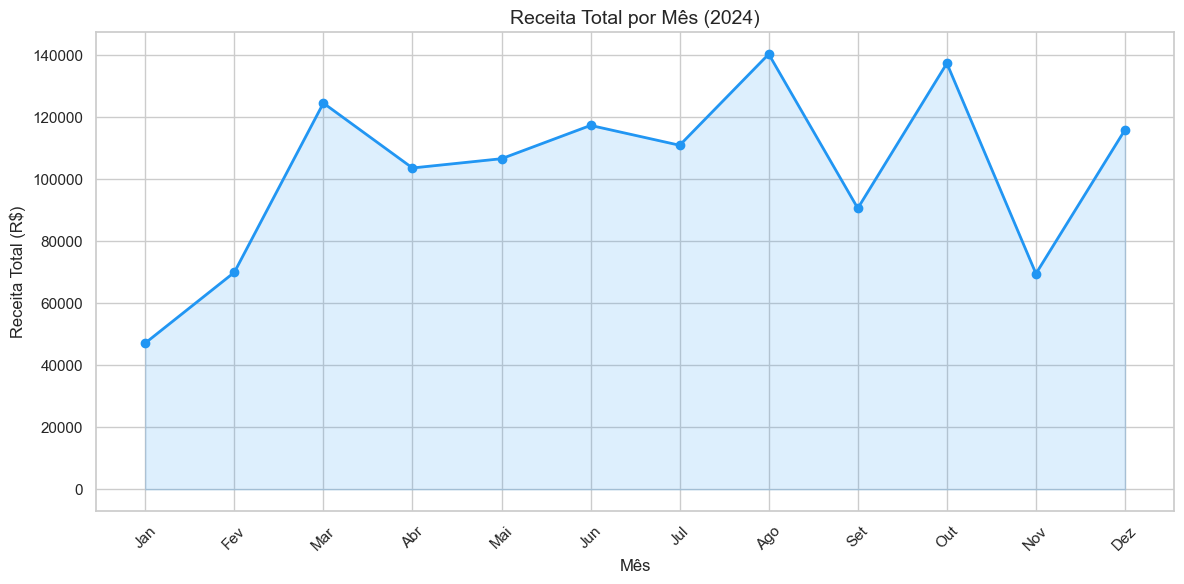

  Gráfico exportado: outputs/graficos\vendas_por_mes.png


C:\Users\PC\AppData\Local\Temp\ipykernel_7952\3991833871.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y="produto", x="receita_total", ax=ax, palette="Blues_d")


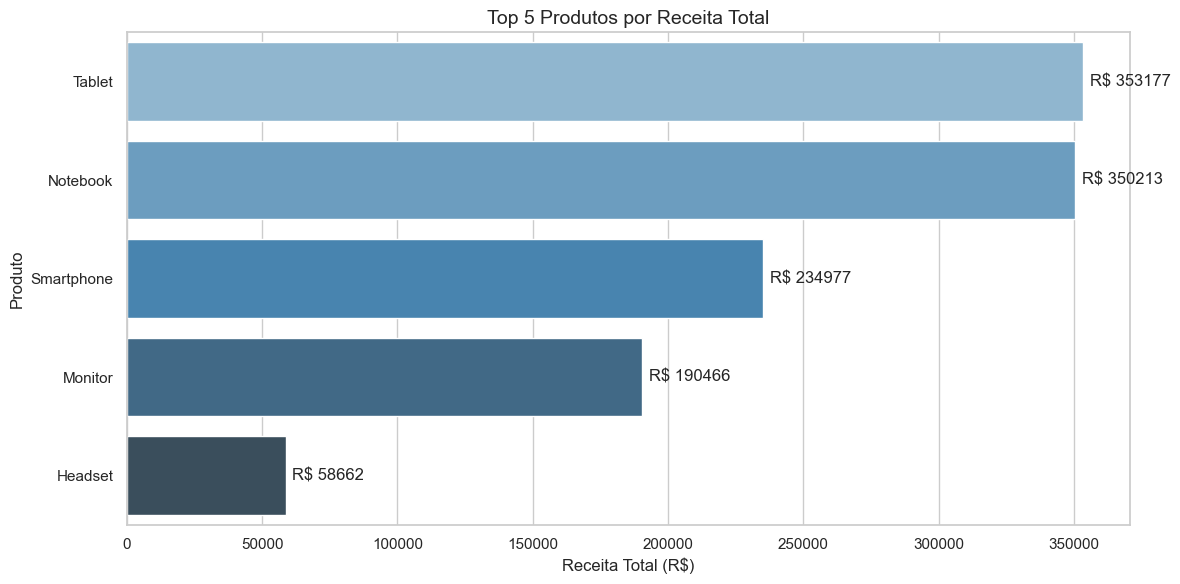

  Gráfico exportado: outputs/graficos\top_produtos.png


C:\Users\PC\AppData\Local\Temp\ipykernel_7952\3991833871.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax, palette="Set2")


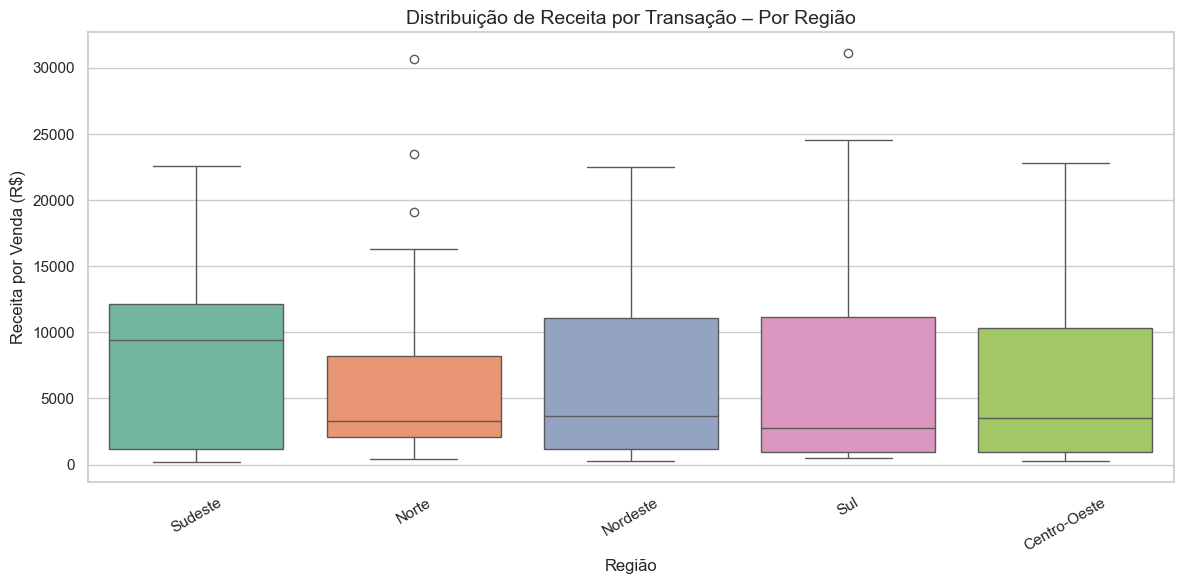

  Gráfico exportado: outputs/graficos\distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS COM SUCESSO ===

[AnalisadorDeVendas] Relatório exportado: outputs/relatorio_resumo.csv

=== LIMPEZA COM REGEX ===
  Clientes com formato inválido encontrados: 0
  Amostra de clientes limpos: ['Cliente_035', 'Cliente_042', 'Cliente_017', 'Cliente_024', 'Cliente_025']

=== ESTATÍSTICAS COM NUMPY ===
  Receita média por venda:    R$ 6855.18
  Receita mediana por venda:  R$ 3899.61
  Desvio padrão:              R$ 6673.94
  Receita total:              R$ 1233932.92
  Percentil 25 (Q1):          R$ 1267.56
  Percentil 75 (Q3):          R$ 10976.68

  Receitas normalizadas (primeiros 5): [0.     0.042  0.3168 0.0247 0.1162]

  Vendas acima da média: 74 de 180
CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

Conteúdo do JSON exportado:
{
  "media": 6855.18,
  "mediana": 3899.61,
  "desvio_padrao": 6673.94,
  "to

In [35]:
def main():
    """
    Função principal: executa o pipeline completo do SalesInsight PY.
    """
    print("\n" + "="*60)
    print("   SALESINSIGHT PY – Pipeline de Análise de Dados de Vendas")
    print("="*60)

    # Etapa 0: Gerar dataset (se necessário)
    if not os.path.exists("vendas.csv"):
        print("\n[INFO] Gerando dataset sintético...")
        df_gerado = gerar_dataset_vendas(n_registros=200)
        df_gerado.to_csv("vendas.csv", index=False)

    # Etapa 1 a 6: Pipeline via classe com herança
    analisador = AnalisadorComProjecao("vendas.csv", meses_projecao=3)
    (analisador
        .carregar()
        .limpar()
        .transformar()
        .analisar()
        .projetar_tendencia()
        .visualizar()
        .exportar_relatorio()
    )

    # Etapa extra: limpeza com regex
    analisador.df_limpo = limpar_strings_com_regex(analisador.df_limpo)

    # Etapa extra: exportação JSON
    stats = calcular_estatisticas_numpy(analisador.df_limpo)
    exportar_resultados(analisador.metricas, analisador.clientes, stats)

    # Resumo final
    analisador.resumo()
    analisador.exibir_projecao_detalhada()

    print("\n[CONCLUÍDO] Pipeline finalizado com sucesso!")


if __name__ == "__main__":
    main()
